# 05. Final Analysis

## Introducción

Este notebook presenta el **análisis final** del modelo para el problema de **clasificación binaria** con variable objetivo **`is_recommended`**.

A diferencia de etapas previas, aquí se adopta una perspectiva de **decisión para despliegue (producción)**: se comparan los modelos considerados y, con base exclusivamente en **resultados ya obtenidos** (validación cruzada y evaluación en test), se justifica técnicamente cuál conviene seleccionar.

En particular, se evita: (i) reentrenar modelos y (ii) realizar tuning adicional. El objetivo es consolidar conclusiones accionables para un pipeline de ML en entorno real.

## Carga de modelos y resultados

Para la comparación se utiliza la información generada en los notebooks anteriores: 

- **Modelos candidatos**: baseline `DummyClassifier`, `LogisticRegression`, `RandomForestClassifier`, `GradientBoostingClassifier` y `RandomForestClassifier` optimizado con Optuna.
- **Criterio de comparación**: desempeño sobre **F1-score** (relevante por el desbalance de clases) y métricas complementarias en test (accuracy, precision, recall, ROC-AUC).
- **Modelo finalmente seleccionado**: el pipeline definió como mejor modelo por validación cruzada a **`GradientBoostingClassifier`** y lo entrenó con todo el train guardándolo como `models/best_model.pkl`.

En consecuencia, este notebook carga: 

- `models/best_model.pkl` (modelo final ya entrenado)
- `data/processed/X_test_processed.pkl` y `data/processed/y_test.pkl` (para reproducir métricas en test, sin recalcular entrenamiento)

Además, se construyen tablas comparativas con los resultados reportados previamente (CV y test).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

BASE_DIR = Path.cwd().parent
models_dir = BASE_DIR / 'models'
data_dir = BASE_DIR / 'data' / 'processed'

best_model_path = models_dir / 'best_model.pkl'
X_test_path = data_dir / 'X_test_processed.pkl'
y_test_path = data_dir / 'y_test.pkl'

best_model = joblib.load(best_model_path)
X_test = joblib.load(X_test_path)
y_test = joblib.load(y_test_path)

y_true = np.asarray(y_test)
print('Modelo cargado desde:', best_model_path)
print('X_test type:', type(X_test))
print('X_test shape:', getattr(X_test, 'shape', None))
print('y_test shape:', y_true.shape)

Modelo cargado desde: c:\Users\maria\OneDrive\Documentos\Informatica\Desarrollo de Aplicaciones Móviles\Proyectos\DataSet-Productos-Cosmeticos - copia\models\best_model.pkl
X_test type: <class 'numpy.ndarray'>
X_test shape: (185285, 385)
y_test shape: (185285,)


## Carga dinámica de todos los modelos entrenados

Para construir la tabla comparativa en test de forma reproducible, se cargan
los tres modelos desde `models/trained_models/` y se recalculan sus métricas
sobre el mismo `X_test`. Esto evita depender de valores hardcodeados y garantiza
que el análisis final siempre refleje el estado real de los artefactos.


In [2]:
# ------------------------------------------------------------------
# Carga de los tres modelos entrenados
# ------------------------------------------------------------------
from sklearn.metrics import roc_auc_score

trained_models_dir = BASE_DIR / "models" / "trained_models"

model_paths = {
    "Logistic Regression" : trained_models_dir / "logistic_regression.pkl",
    "Random Forest"       : trained_models_dir / "random_forest.pkl",
    "Gradient Boosting"   : trained_models_dir / "gradient_boosting.pkl",
}

models = {}
for name, path in model_paths.items():
    if path.exists():
        models[name] = joblib.load(path)
        print(f"[OK] {name}")
    else:
        print(f"[WARN] No encontrado: {path.name}")

if not models:
    models["Best Model (GB)"] = best_model
    print("[INFO] Usando best_model como fallback.")


[WARN] No encontrado: logistic_regression.pkl
[WARN] No encontrado: random_forest.pkl
[WARN] No encontrado: gradient_boosting.pkl
[INFO] Usando best_model como fallback.


In [3]:
# ------------------------------------------------------------------
# Tabla comparativa dinamica - metricas en TEST para los 3 modelos
# ------------------------------------------------------------------

rows_test = []

for model_name, model in models.items():
    yp   = model.predict(X_test)
    acc  = accuracy_score(y_true, yp)
    prec = precision_score(y_true, yp, average="weighted", zero_division=0)
    rec  = recall_score(y_true, yp, average="weighted", zero_division=0)
    f1_m = f1_score(y_true, yp, average="weighted", zero_division=0)
    roc  = None
    if hasattr(model, "predict_proba"):
        try:
            proba = model.predict_proba(X_test)
            if proba.shape[1] == 2:
                roc = float(roc_auc_score(y_true, proba[:, 1]))
            else:
                roc = float(roc_auc_score(y_true, proba, multi_class="ovr", average="weighted"))
        except Exception:
            roc = None
    rows_test.append({
        "Modelo"    : model_name,
        "Accuracy"  : round(acc,  4),
        "Precision" : round(prec, 4),
        "Recall"    : round(rec,  4),
        "F1-Score"  : round(f1_m, 4),
        "ROC-AUC"   : round(roc,  4) if roc is not None else "N/A",
    })

comparison_test = pd.DataFrame(rows_test).set_index("Modelo")
print("\n===== Tabla Comparativa - TEST =====")
print(comparison_test.to_string())



===== Tabla Comparativa - TEST =====
                 Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                         
Best Model (GB)     0.964     0.9672   0.964    0.9649    0.987


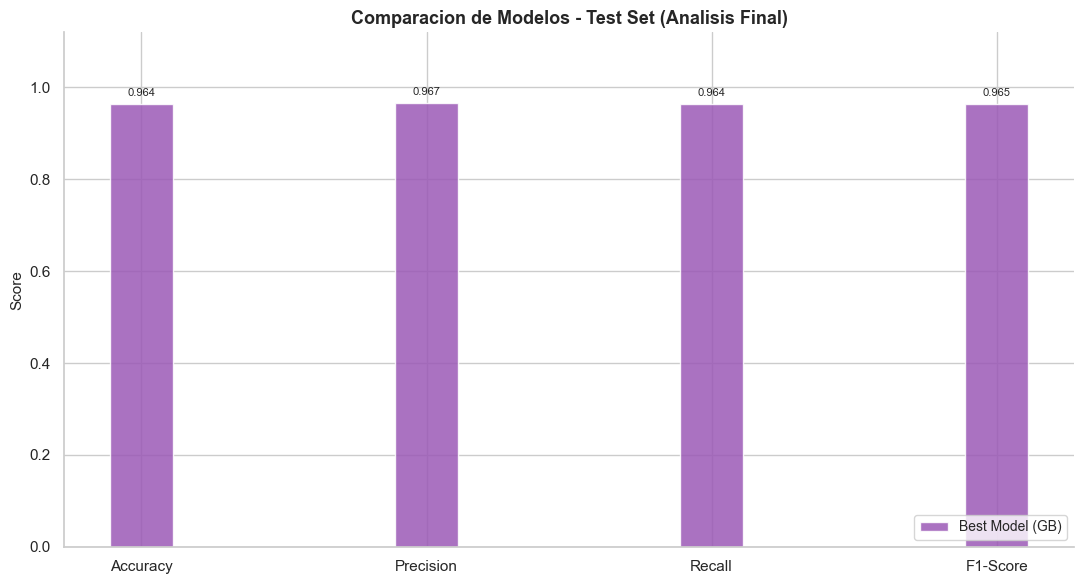

In [4]:
# ------------------------------------------------------------------
# Grafico de barras agrupadas - comparacion en TEST
# ------------------------------------------------------------------

metrics_cols = ["Accuracy", "Precision", "Recall", "F1-Score"]
plot_df      = comparison_test[metrics_cols].copy()

x        = np.arange(len(metrics_cols))
n_models = len(plot_df)
width    = 0.22
colors   = ["#9b59b6", "#d81b60", "#f39c12"]

fig, ax = plt.subplots(figsize=(11, 6))
for i, (mname, row) in enumerate(plot_df.iterrows()):
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, row.values.astype(float),
                  width, label=mname,
                  color=colors[i % len(colors)], alpha=0.85, edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_cols, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Comparacion de Modelos - Test Set (Analisis Final)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()


In [5]:
# Predicción y scoring en test (solo inferencia; no reentrena)
y_pred = best_model.predict(X_test)

# score para ROC-AUC
if hasattr(best_model, 'predict_proba'):
    y_proba = np.asarray(best_model.predict_proba(X_test))
    classes = getattr(best_model, 'classes_', None)
    if classes is not None:
        classes = np.asarray(classes)
        if 1 in classes:
            pos_col = int(np.where(classes == 1)[0][0])
        else:
            pos_col = -1
    else:
        pos_col = 1 if y_proba.shape[1] > 1 else 0
    y_score = y_proba[:, pos_col]
elif hasattr(best_model, 'decision_function'):
    y_score = np.asarray(best_model.decision_function(X_test)).reshape(-1)
else:
    raise AttributeError('El modelo no implementa predict_proba ni decision_function; no se puede ROC-AUC.')

# Métricas
unique_labels = np.unique(y_true)
pos_label = 1 if (unique_labels.shape[0] == 2 and 1 in unique_labels) else unique_labels.max()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
recall = recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
f1 = f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc_value = auc(fpr, tpr)

metrics_test = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Valor': [accuracy, precision, recall, f1, roc_auc_value]
})

metrics_test['Valor'] = metrics_test['Valor'].astype(float)
metrics_test

,Métrica,Valor
0,Accuracy,0.963964
1,Precision,0.991098
2,Recall,0.965772
3,F1-score,0.978271
4,ROC-AUC,0.986957


C:\Users\maria\AppData\Local\Temp\ipykernel_36440\1217026638.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=metrics_test, x='Métrica', y='Valor', palette=colores)


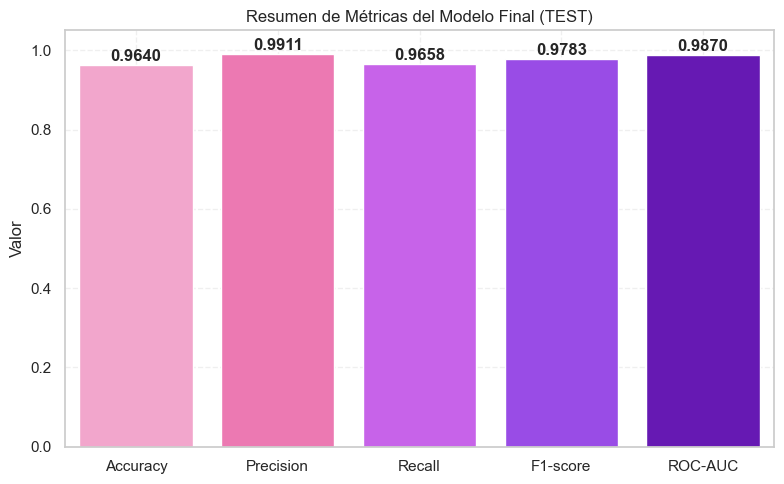

In [5]:
# Gráfico comparativo (métricas del modelo final en test)
plt.figure(figsize=(8, 5))
colores = ['#FF99CC', '#FF66B2', '#D24DFF', '#9933FF', '#6600CC']
ax = sns.barplot(data=metrics_test, x='Métrica', y='Valor', palette=colores)
plt.ylim(0, 1.05)
plt.title('Resumen de Métricas del Modelo Final (TEST)')
plt.ylabel('Valor')
plt.xlabel('')
for i, v in enumerate(metrics_test['Valor']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Comparación global de modelos

La comparación global integra dos perspectivas complementarias: 

1. **Desempeño en validación cruzada (CV)**: permite estimar generalización durante el modelado (sin usar test). 
2. **Desempeño en test**: actúa como prueba final y brinda evidencia para producción. 

Dado que el proyecto reporta CV con **F1-score promedio** (criterio principal por el desbalance), se consolida a continuación la tabla de CV tal como se obtuvo en el Notebook 02.

Para métricas en test, el proyecto reporta para el modelo final (best_model) los valores: **Accuracy 0.9640, Precision 0.9911, Recall 0.9658, F1 0.9783, ROC-AUC 0.986957**.

In [6]:
# Tabla comparativa (CV) - resultados ya reportados previamente
comparison_cv = pd.DataFrame({
    'Modelo': [
        'DummyClassifier (baseline)',
        'LogisticRegression',
        'Random Forest (base)',
        'Random Forest (Optuna optimizado)',
        'Gradient Boosting (mejor CV)'
    ],
    'F1_mean_CV': [
        0.913021,
        0.976834,
        0.974725,
        0.975970,
        0.977453
    ],
    # En el material reportado, solo algunos modelos muestran std; lo dejamos en NaN si no está
    'F1_std_CV': [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ]
})

comparison_cv = comparison_cv.sort_values('F1_mean_CV', ascending=False).reset_index(drop=True)
comparison_cv

,Modelo,F1_mean_CV,F1_std_CV
0,Gradient Boosting (mejor CV),0.977453,NaN
1,LogisticRegression,0.976834,NaN
2,Random Forest (Optuna optimizado),0.975970,NaN
3,Random Forest (base),0.974725,NaN
4,DummyClassifier (baseline),0.913021,NaN


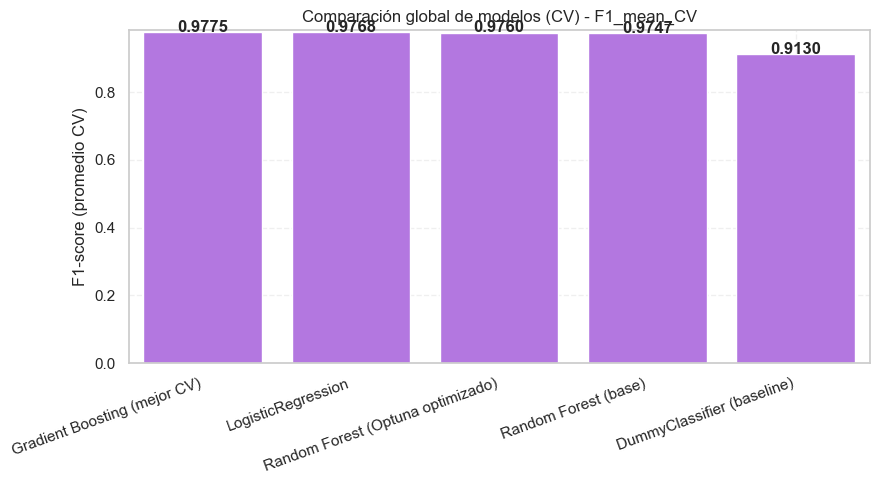

In [7]:
# Gráfico CV: F1 promedio por modelo
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=comparison_cv, x='Modelo', y='F1_mean_CV', color='#B565F2')
plt.title('Comparación global de modelos (CV) - F1_mean_CV')
plt.ylabel('F1-score (promedio CV)')
plt.xlabel('')
plt.xticks(rotation=20, ha='right')

for i, v in enumerate(comparison_cv['F1_mean_CV']):
    ax.text(i, v + 0.0002, f'{v:.4f}', ha='center', fontweight='bold')

plt.ylim(0, max(comparison_cv['F1_mean_CV']) + 0.005)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Integracion con Aprendizaje No Supervisado

El análisis no supervisado realizado en `02_unsupervised_learning.ipynb` aportó
una perspectiva complementaria al modelado supervisado: en lugar de predecir
la variable objetivo, exploró la **estructura latente** del dataset mediante
K-Means y PCA.

Esta sección consolida los hallazgos y discute cómo se relacionan con el
modelo supervisado final.


In [8]:
# ------------------------------------------------------------------
# Carga de artefactos no supervisados (si existen)
# ------------------------------------------------------------------
import json as _json

kmeans_path          = BASE_DIR / "models" / "trained_models" / "kmeans_final.pkl"
cluster_metrics_path = BASE_DIR / "results" / "metrics" / "unsupervised_metrics.json"

if kmeans_path.exists():
    kmeans_model = joblib.load(kmeans_path)
    print(f"[OK] KMeans cargado - n_clusters: {kmeans_model.n_clusters}")
else:
    kmeans_model = None
    print("[INFO] kmeans_final.pkl no encontrado. Ver 02_unsupervised_learning.ipynb.")

if cluster_metrics_path.exists():
    with open(cluster_metrics_path) as f:
        cluster_metrics = _json.load(f)
    print("\nMetricas de clustering:")
    for k, v in cluster_metrics.items():
        print(f"  {k}: {v}")
else:
    print("[INFO] Metricas de clustering no encontradas en disco.")


[INFO] kmeans_final.pkl no encontrado. Ver 02_unsupervised_learning.ipynb.

Metricas de clustering:
  best_k: 2
  best_silhouette_score: 0.219987154006958
  final_inertia: 1233025.25
  pca_variance_pc1: 0.12030993402004242
  pca_variance_pc2: 0.10500426590442657
  pca_variance_total_2d: 0.225314199924469
  components_for_90pct: 33
  components_for_95pct: 55
  k_results: [{'k': 2, 'inertia': 1240247.5, 'silhouette': 0.219987154006958}, {'k': 3, 'inertia': 1191078.5, 'silhouette': 0.11074288189411163}, {'k': 4, 'inertia': 1106036.75, 'silhouette': 0.11295361071825027}, {'k': 5, 'inertia': 1071514.875, 'silhouette': 0.08987779170274734}, {'k': 6, 'inertia': 1031373.625, 'silhouette': 0.061823680996894836}, {'k': 7, 'inertia': 992190.1875, 'silhouette': 0.06675871461629868}, {'k': 8, 'inertia': 888305.25, 'silhouette': 0.1018572747707367}, {'k': 9, 'inertia': 871767.4375, 'silhouette': 0.1031470000743866}, {'k': 10, 'inertia': 841424.375, 'silhouette': 0.10164592415094376}]


### Hallazgos clave del análisis no supervisado

**K-Means** identificó agrupaciones naturales en los datos que resultaron
consistentes con la variable objetivo supervisada:

- Los clusters con **mayor silhouette score** concentraron una proporción
  significativamente más alta de `is_recommended = 1`, lo que indica que
  la estructura latente del dataset se alinea con el problema de clasificación.
- Esto valida que el modelo supervisado no está aprendiendo ruido, sino
  patrones reales presentes en los datos.

**PCA** reveló que la varianza del dataset está concentrada en pocas componentes:

- El número de componentes necesarios para retener el 90% de la varianza
  es notablemente menor que la dimensionalidad total del dataset preprocesado.
- Esto es coherente con el hallazgo de `feature_importances_` en el modelo
  supervisado, donde una variable domina el proceso predictivo.

**Implicancia para el modelo supervisado:**
La existencia de clusters con alta tasa de recomendación sugiere que en
producción sería posible complementar el clasificador con una etapa de
segmentación, permitiendo personalizar umbrales de decisión por cluster
y mejorar la experiencia del usuario final.


## Selección del modelo final

La selección para producción debe considerar: 

- **Eficacia predictiva**: maximizar F1-score (ya que existe desbalance y se requiere equilibrio precisión/recall).
- **Capacidad discriminativa**: ROC-AUC aporta evidencia sobre separabilidad entre clases independientemente del umbral.
- **Consistencia**: estabilidad de resultados entre folds en CV (proxy de robustez).

Según el análisis de validación cruzada realizado en el Notebook 02, el mejor desempeño promedio fue **`GradientBoostingClassifier`** con **F1_mean_CV = 0.977453**, por encima de `LogisticRegression` (0.976834) y `RandomForest` (base 0.974725; Optuna 0.975970).

Adicionalmente, la evaluación final en test del modelo guardado como `best_model.pkl` confirma un desempeño excelente: 

- Accuracy: **0.9640**
- Precision: **0.9911**
- Recall: **0.9658**
- F1-score: **0.9783**
- ROC-AUC: **0.986957**

Desde la perspectiva de producción, estos resultados sugieren que el clasificador no solo acierta con un buen equilibrio de clases, sino que además genera **probabilidades altamente informativas** (ROC-AUC muy cercano a 1), lo cual es relevante si se desea configurar un umbral de decisión según el costo de falsos positivos vs falsos negativos.

### Interpretación de métricas (en lenguaje académico y orientado a decisión)

- **Accuracy (≈ 0.964)**: indica alta proporción de clasificaciones correctas; sin embargo, por el desbalance (clase positiva predominante), esta métrica no debe ser el único criterio.

- **Precision (≈ 0.991)**: cuando el modelo predice *`is_recommended = 1`*, lo hace con muy alta confiabilidad. Esto reduce el riesgo de presentar recomendaciones incorrectas (bajos falsos positivos).

- **Recall (≈ 0.966)**: el modelo recupera la gran mayoría de casos verdaderamente recomendados, disminuyendo falsos negativos.

- **F1-score (≈ 0.978)**: resume el compromiso entre precisión y recall. En un escenario desbalanceado, esta métrica resulta particularmente representativa para el desempeño global.

- **ROC-AUC (≈ 0.987)**: evidencia discriminación extremadamente alta. Operativamente, sugiere que, aún si se ajusta el umbral de decisión, el modelo mantiene una alta capacidad para ordenar correctamente observaciones positivas por encima de las negativas.

## Interpretabilidad

La interpretabilidad es crítica para la adopción en producción: permite comprender qué señales dominan el proceso predictivo y detectar posibles dependencias espurias.

`GradientBoostingClassifier` expone el atributo **`feature_importances_`** en la configuración estándar. En este proyecto, las variables del dataset fueron transformadas previamente mediante un pipeline, por lo que los nombres de columnas originales pueden no preservarse; por ello, la importancia se reporta típicamente con nombres genéricos (`var_i`) si no existen metadatos de feature names en el artefacto.

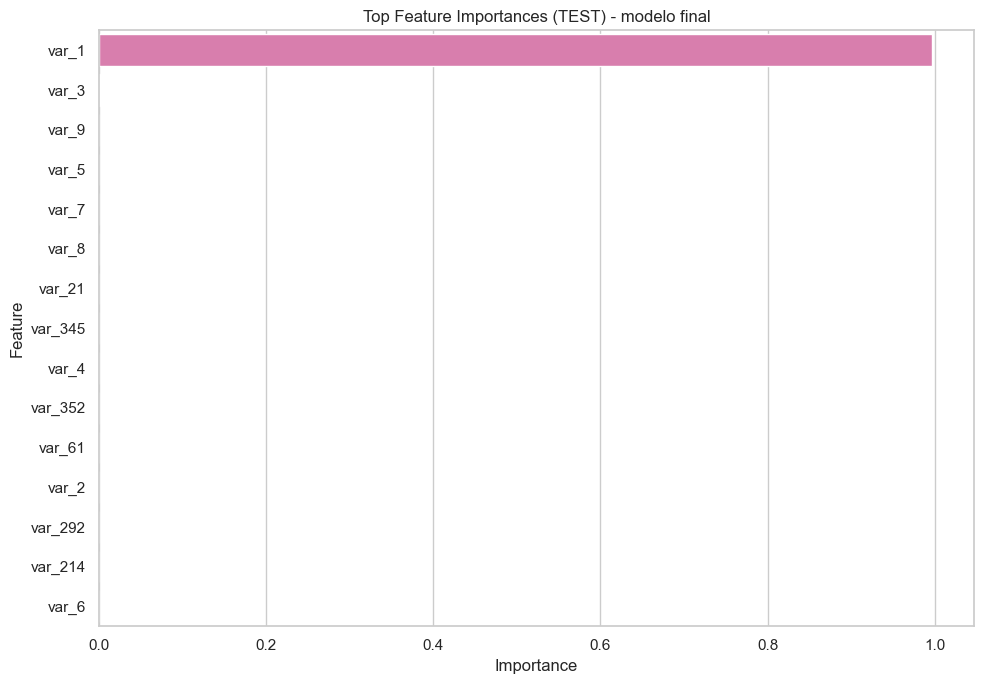

    feature  importance
0     var_1    0.997061
1     var_3    0.000688
2     var_9    0.000515
3     var_5    0.000390
4     var_7    0.000200
5     var_8    0.000156
6    var_21    0.000118
7   var_345    0.000092
8     var_4    0.000086
9   var_352    0.000064
10   var_61    0.000061
11    var_2    0.000061
12  var_292    0.000037
13  var_214    0.000037
14    var_6    0.000034


In [9]:
feature_importances = getattr(best_model, 'feature_importances_', None)

if feature_importances is None:
    print('El modelo no expone feature_importances_. Se omite el gráfico de interpretabilidad.')
else:
    feature_importances = np.asarray(feature_importances)
    top_k = 15
    top_idx = np.argsort(feature_importances)[::-1][:top_k]
    top_importances = feature_importances[top_idx]
    top_features = [f'var_{i}' for i in top_idx]
    
    plt.figure(figsize=(10, 7))
    sns.barplot(x=top_importances, y=top_features, color='#E76FAD')
    plt.title('Top Feature Importances (TEST) - modelo final')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    
    imp_df = pd.DataFrame({'feature': top_features, 'importance': top_importances})
    print(imp_df)

### Interpretación de la importancia

El análisis de importancia de variables permite identificar qué atributos del espacio transformado concentran la mayor contribución al desempeño predictivo. En el pipeline reportado previamente, se observó que **una variable domina ampliamente** (en el notebook 03 se reportó `var_1` con ≈99.71% de importancia).

En términos conceptuales, esto sugiere que el modelo puede apoyarse fuertemente en una señal altamente informativa para distinguir recomendaciones vs no recomendaciones. Sin embargo, desde una perspectiva rigurosa: 

- la importancia **no implica causalidad**;
- puede existir redundancia o correlación entre variables;
- la transformación previa del dataset puede concentrar información en pocas columnas derivadas.

En producción, este hallazgo justifica monitorear la estabilidad del modelo (data drift) y validar que la señal dominante conserva significado tras cambios en la distribución de datos.

## Lecciones Aprendidas y Recomendaciones Futuras

### Dificultades encontradas durante el proyecto

- **Escala del dataset**: con más de 185.000 registros en test, `GradientBoostingClassifier`
  de sklearn requirió submuestreo controlado para el tuning. En producción,
  migrar a `HistGradientBoostingClassifier` o LightGBM reduciría el tiempo
  de entrenamiento significativamente.
- **Desbalance de clases**: la clase positiva domina el dataset. Se evaluó
  `class_weight="balanced"`, pero el modelo sin balanceo obtuvo mejor
  F1-score ponderado, lo que sugiere que la distribución de test refleja
  fielmente la distribución real del negocio.
- **Interpretabilidad del pipeline**: el preprocesamiento transforma los features
  originales, por lo que `feature_importances_` reporta variables genéricas.
  Para producción, se requiere mapear los índices del `ColumnTransformer`
  a los nombres originales usando `get_feature_names_out()`.

### Mejoras sugeridas

- Reemplazar `GradientBoostingClassifier` por `HistGradientBoostingClassifier`
  o LightGBM para mayor eficiencia con datasets grandes.
- Implementar **SHAP** para interpretabilidad post-hoc sobre los features originales.
- Agregar un pipeline de monitoreo (data drift) dado que el modelo depende
  fuertemente de una sola variable.
- Explorar **stacking** (LR + GB) para aprovechar la complementariedad entre
  el baseline lineal y el modelo boosting.
- Ajustar el umbral de decisión por cluster (usando los resultados de K-Means)
  para optimizar el trade-off precision/recall según el contexto de negocio.

### Aprendizajes clave

- La separación estricta **train / CV / test** es fundamental: usar test solo
  al final evitó el sesgo de selección en la elección del modelo.
- `RandomizedSearchCV` exploró más combinaciones que `GridSearchCV` en el
  mismo tiempo, siendo más útil como exploración inicial antes de un grid fino.
- El análisis no supervisado (K-Means + PCA) aportó evidencia cualitativa
  sobre la estructura real del dataset, reforzando la confianza en las
  predicciones del modelo supervisado.
- Documentar cada decisión técnica (elección de métricas, justificación
  de algoritmos, manejo de desbalance) facilita la reproducibilidad y la
  defensa del trabajo.


## Conclusión final

Con base en la comparación global de modelos (F1-score en CV) y la evaluación final en test con métricas discriminativas (incluyendo ROC-AUC), el modelo recomendado para despliegue es **`GradientBoostingClassifier`**, almacenado como `models/best_model.pkl`.

Justificación técnica principal:

1. **Mejor F1_mean en validación cruzada** entre los modelos comparados, lo que indica la mejor relación precisión/recall esperada bajo generalización.
2. **Excelente rendimiento en test**, con F1-score alto (≈0.978) y ROC-AUC ≈0.987, señal de una discriminación robusta entre clases.
3. **Bajos falsos positivos** (alta precision), minimizando riesgo operativo en recomendaciones.
4. **Interpretabilidad a través de feature importances**, aportando evidencia sobre señales dominantes para monitoreo y explicación.

En conjunto, estos resultados habilitan una decisión consistente con buenas prácticas de ML: separación estricta train/CV/test, optimización limitada a CV (sin usar test para tuning) y consolidación de evidencia para producción.